In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from utils.data_manipulations import add_site_id

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import linregress

In [3]:
from utils.visualisation_functions import *

# Energy mix

In [4]:
df_energy = pd.read_excel(r'data/MetalliCan/pre_cleaned_data/energy_df.xlsx')
prod_data = pd.read_excel(r'data/MetalliCan/sites_for_lci.xlsx', sheet_name='prod_data')

In [5]:
df_energy = add_site_id(df_energy)
prod_data = add_site_id(prod_data)

In [6]:
df_energy = pd.merge(df_energy, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')

In [7]:
remove = ['Energy use', 'Other', 'Acetylene', 'Ammonium nitrate']
df_energy = df_energy[~df_energy['subflow_type'].isin(remove)]

In [8]:
df_energy.to_csv(r'df_energy.csv', index=False)

In [9]:
from utils.constants import nrj_subflow

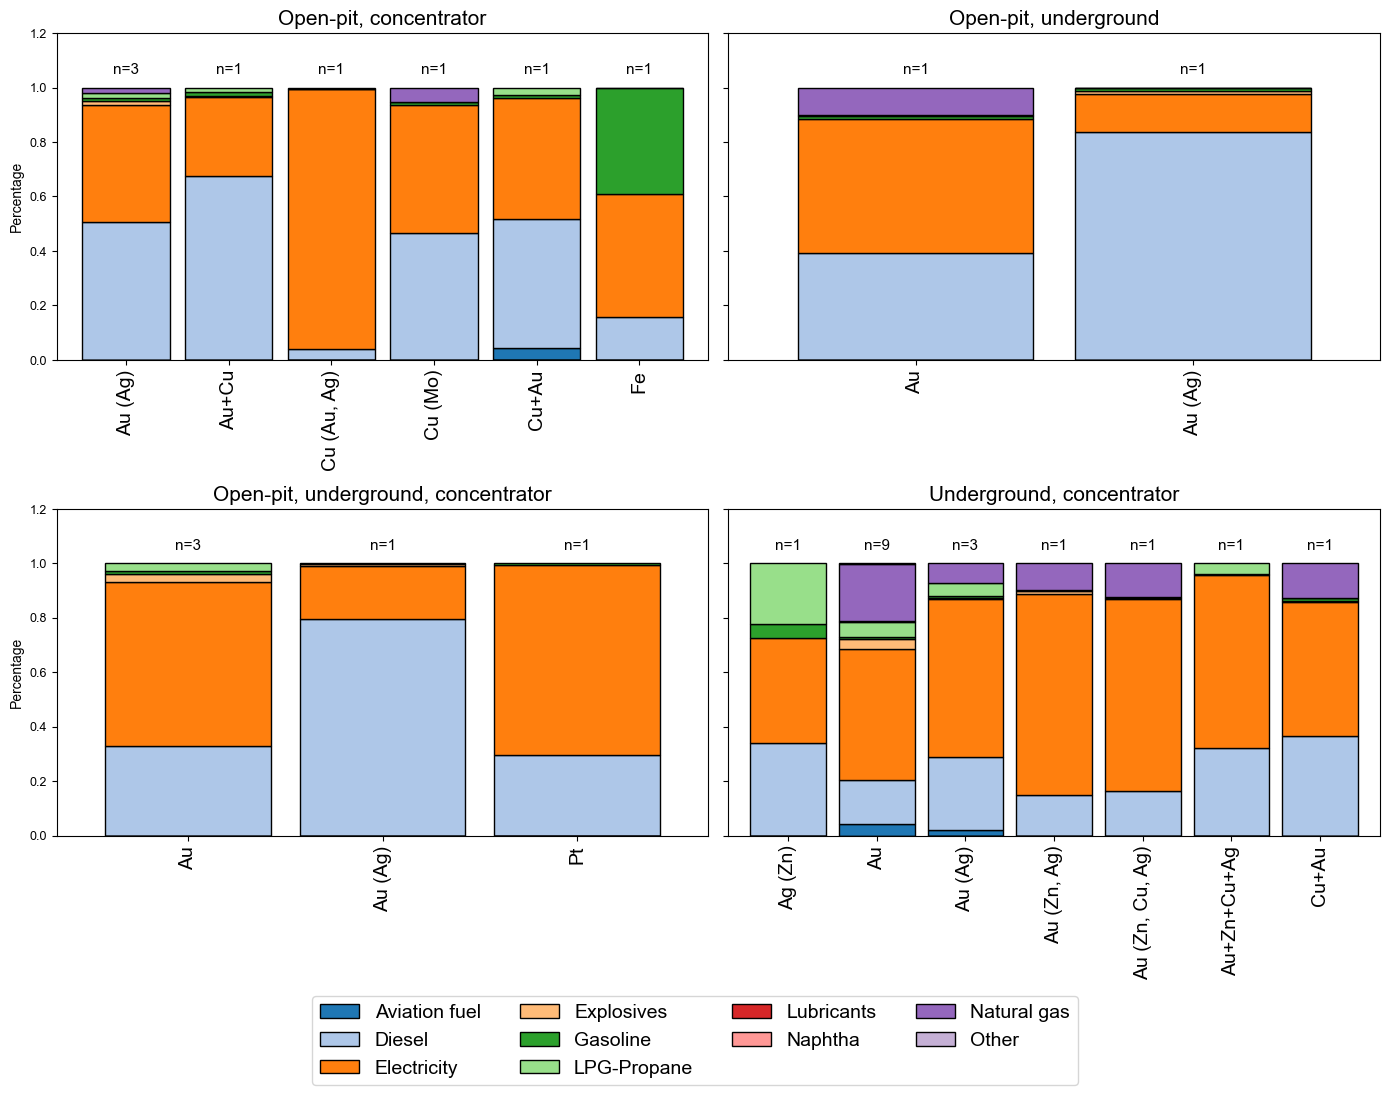

In [10]:
df_energy_mix = plot_energy_mix_archetypes(df_energy, nrj_subflow, savepath=r'data/Parametrization/energy_mix_archetypes')

In [11]:
df_energy_mix.to_csv(r'data/Parametrization/energy_mix_stats.csv', index=False)

# Grade

## Import data

In [12]:
biosphere_df = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/economic_allocation/biosphere_df.csv')
water_df = biosphere_df[biosphere_df['substance_name'] == 'Water']

In [13]:
substance_of_interest = ['Lead (and its compounds)', 'Arsenic (and its compounds)', 'Cobalt (and its compounds)', 'Cadmium (and its compounds)', 'Copper (and its compounds)', 'Zinc (and its compounds)', 'Manganese (and its compounds)']

In [14]:
npri_df = biosphere_df[biosphere_df['substance_name'].isin(substance_of_interest)]

In [15]:
npri_df = add_site_id(npri_df)

In [16]:
npri_df.rename(columns={'unit': 'unit_substance'}, inplace=True)

In [17]:
energy_df_metal = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/economic_allocation/energy_df.csv')
energy_df_ore = pd.read_csv(r'data/MetalliCan/data_for_lci_initialization/ore_normalization/energy_df.csv')
ta_df = pd.read_csv(r'data/MetalliCan/pre_cleaned_data/ta_table.csv')
material_nrj = pd.read_csv(r'C:\Users\mp_ma\OneDrive - polymtl\POST_DOC\CODE\metallican_db\database\CSV\materials_energy_table.csv')
prod_data = pd.read_excel(r'data/MetalliCan/sites_for_lci.xlsx', sheet_name='prod_data')

In [18]:
prod_data = add_site_id(prod_data)
material_nrj_table = add_site_id(material_nrj)

In [19]:
# Let's exclude the mines for which we don't know if Au or others are the main product
multiple_com_mines = ['BC-MAIN-599152a0', 'BC-MAIN-6b4800fe', 'ON-MAIN-f8313ebd', 'BC-MAIN-ed23117f', 'BC-MAIN-aa76f6f2', 'BC-MAIN-8eb8be0d', 'QC-MAIN-a97821c0',
'MB-MAIN-e0a6250e', 'NL-MAIN-2d8801d6'] # Copper Mountain, Gibraltar + Kidd Creek, Mount Milligan, New Afton, Red Chris, Raglan, Thompson, Voisey's Bay, Nunanick Nickel, Snow Lake ('GRP-a13779f8')
cu_mines = ['BC-MAIN-599152a0', 'BC-MAIN-6b4800fe'] # Copper Mountain, Gibraltar
fe_mines = ['NL-MAIN-dd723db4'] # Carol Lake
ag_mines = ['YT-MAIN-44857446'] # Keno Hill
pt_mines = ['ON-MAIN-a3c56a83'] # Lac des Iles

In [20]:
unique_to_ta = ta_df[~ta_df['site_id'].isin(material_nrj_table['site_id'])]['site_id'].unique()
unique_to_ta

array(['QC-MAIN-089f3c60', 'ON-MAIN-de2f9639', 'ON-MAIN-52224e1e',
       'BC-MAIN-4724f4ba', 'ON-MAIN-4e0734b5', 'ON-MAIN-48fe2205',
       'BC-MAIN-bf503b6b', 'ON-MAIN-f8313ebd', 'MB-MAIN-be5b3dc8',
       'ON-MAIN-8825d90d', 'ON-MAIN-7001a391', 'BC-MAIN-3f490561',
       'MB-MAIN-da0b5c3d', 'MB-MAIN-0898e255', 'ON-MAIN-f4fc3276',
       'AB-MAIN-d3a4aba9', 'ON-MAIN-28f3f0fc'], dtype=object)

In [21]:
unique_to_mat_nrj = material_nrj_table[~material_nrj_table['site_id'].isin(ta_df['site_id'])]['site_id'].unique()
unique_to_mat_nrj

array(['NL-MAIN-dd723db4', 'NL-MAIN-b64bae7a'], dtype=object)

## Data treatment

In [22]:
energy_df_au = energy_df_metal[~energy_df_metal['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
energy_df_ore = energy_df_ore[~energy_df_ore['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
ta_df_au = ta_df[~ta_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
npri_df_au = npri_df[~npri_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]
water_df_au = water_df[~water_df['site_id'].isin(multiple_com_mines+cu_mines+fe_mines+ag_mines+pt_mines)]

In [23]:
# energy_df = energy_df[energy_df['site_id'].isin(multiple_com_mines)]
# ta_df = ta_df[ta_df['site_id'].isin(multiple_com_mines)]

In [24]:
grades_df_au = ta_df_au[ta_df_au['material_type'].str.contains('grade', case=False, na=False)].copy()
grades_df_au = grades_df_au[grades_df_au['material_type']!='Concentrate grade']
grades_df_au['grade_percent'] = grades_df_au.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [25]:
# grades_df_cu = ta_df_cu[ta_df_cu['material_type'].str.contains('grade', case=False, na=False)].copy()
# grades_df_cu = grades_df_cu[grades_df_cu['material_type']!='Concentrate grade']
# grades_df_cu['grade_percent'] = grades_df_cu.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [26]:
# grades_df = ta_df[ta_df['material_type'].str.contains('grade', case=False, na=False)].copy()
# grades_df = grades_df_cu[grades_df['material_type']!='Concentrate grade']
# grades_df['grade_percent'] = grades_df.apply(lambda row: row['value'] * 0.0001 if 'g/t' in str(row['unit']).lower() else row['value'], axis=1)

In [27]:
energy_total_au = (energy_df_au.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
energy_total_ore = (energy_df_ore.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
# energy_total_cu = (energy_df_cu.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))
# energy_total = (energy_df.groupby('site_id', as_index=False)['value_normalized'].sum().rename(columns={'value_normalized': 'total_energy_normalized'}))

In [28]:
npri_df_au = npri_df_au[npri_df_au['metal'] == 'Au']
water_df_au = water_df_au[water_df_au['metal'] == 'Au']

In [29]:
df_au_nrj = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                     energy_total_au,
                     on='site_id',
                     how='left')
df_au_nrj = pd.merge(df_au_nrj, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_nrj = df_au_nrj[df_au_nrj['commodity'] == 'Gold']
df_au_nrj['total_energy_normalized'] = df_au_nrj['total_energy_normalized'] / 1000 # To have in GJ/t Au


In [30]:
df_au_npri = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                      npri_df_au[['site_id', 'facility_group_id', 'compartment_name', 'substance_name', 'flow_direction', 'release_pathway', 'unit_substance', 'value_normalized']],
                      on='site_id',
                      how='left')
df_au_npri = pd.merge(df_au_npri, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_npri = df_au_npri[df_au_npri['commodity'] == 'Gold']


In [31]:
water_df_au = water_df_au[water_df_au['flow_direction'] == 'Consumption']

In [32]:
# Remove rows where the value_normalized is negative
water_df_au = water_df_au[water_df_au['value_normalized'] >= 0]

In [33]:
df_au_water = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
                      water_df_au[['site_id', 'value_normalized']],
                      on='site_id',
                      how='left')
df_au_water = pd.merge(df_au_water, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
df_au_water = df_au_water[~df_au_water['value_normalized'].isna()]
df_au_water = df_au_water[df_au_water['commodity'] == 'Gold']

In [34]:
# df_ore = pd.merge(grades_df_au[['site_id', 'commodity', 'material_type', 'facility_name', 'unit', 'value', 'grade_percent']],
#                   energy_total_ore,
#                   on='site_id',
#                   how='left')
# df_ore = pd.merge(df_ore, prod_data[['site_id', 'mining_processing_type', 'Main_product']], on='site_id', how='left')
# df_ore = df_ore[df_ore['commodity'] == 'Gold']

In [35]:
# df_cu = pd.merge(grades_df_cu[['site_id', 'commodity', 'material_type', 'facility_name', 'grade_percent']], energy_total_cu, on='site_id', how='left')
# df_cu = pd.merge(df_cu, prod_data[['site_id', 'Main_product']], on='site_id', how='left')
# df_cu = df_cu[df_cu['commodity'] == 'Copper']

In [36]:
# df = pd.merge(grades_df[['site_id', 'commodity', 'material_type', 'facility_name', 'grade_percent']], energy_total, on='site_id', how='left')
# df = pd.merge(df_cu, prod_data[['site_id', 'Main_product']], on='site_id', how='left')
# df = df[df['commodity'] == 'Copper']

In [37]:
df_au_npri = df_au_npri[df_au_npri['facility_name'] != 'Timmins West' ]

In [38]:
df_au_npri["value_normalized"] = df_au_npri.groupby(["site_id", "compartment_name", "substance_name", "flow_direction"])["value_normalized"].transform("sum")
df_au_npri = df_au_npri.drop(columns=["release_pathway"]).drop_duplicates()

In [39]:
df_au_npri_arsenic = df_au_npri[df_au_npri['substance_name'] == 'Arsenic (and its compounds)']
df_au_npri_cadmium = df_au_npri[df_au_npri['substance_name'] == 'Cadmium (and its compounds)']
df_au_npri_cobalt = df_au_npri[df_au_npri['substance_name'] == 'Cobalt (and its compounds)']
df_au_npri_copper = df_au_npri[df_au_npri['substance_name'] == 'Copper (and its compounds)']
df_au_npri_lead = df_au_npri[df_au_npri['substance_name'] == 'Lead (and its compounds)']
df_au_npri_manganese = df_au_npri[df_au_npri['substance_name'] == 'Manganese (and its compounds)']
df_au_npri_zinc = df_au_npri[df_au_npri['substance_name'] == 'Zinc (and its compounds)']

In [40]:
df_au_nrj.to_csv(r'data/Parametrization/au_nrj_relationship.csv', index=False)
df_au_npri.to_csv(r'data/Parametrization/au_npri_relationship.csv', index=False)
df_au_water.to_csv(r'data/Parametrization/au_water_relationship.csv', index=False)

## Plotting

In [41]:
df_au_nrj_t = df_au_nrj[df_au_nrj['facility_name'] != 'Eagle River']

In [42]:
plot_grade_relationship(df_au_nrj_t, x_col='value', y_abs='GJ/t Au', output_html='data/Parametrization/au_nrj_relationship_without_outliers.html')

In [49]:
plot_grade_relationship(df_au_nrj, x_col='value', y_abs='GJ/t Au', output_html='data/Parametrization/au_nrj_relationship.html')


In [44]:
plot_grade_relationship(df_au_water, x_col='value', y_col='value_normalized', y_abs='m3/t Au', output_html='data/Parametrization/au_water_relationship.html')

In [46]:
plot_grade_relationship(df_au_npri_arsenic, x_col='value', y_col='value_normalized', y_abs='kg Arsenic/t Au', output_html='data/Parametrization/au_arsenic_relationship.html')

In [47]:
plot_grade_relationship(df_au_npri_cadmium, x_col='value', y_col='value_normalized', y_abs='kg Cadmium/t Au', output_html='data/Parametrization/au_cadmium_relationship.html')

In [83]:
plot_grade_relationship(df_ore, x_col='value', y_abs='MJ/t ore', output_html='data/Parametrization/au_nrj_relationship_ore.html')